# Sample Reconstruction Using Sinc(t) to Interpolate

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()

import control_materials as cm
print("Control Material version:", cm.__version__)
cm.setup_environment()


Basic Material version: 16.002-0.1


Control Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Create sampled signal

In [4]:
fs = 10                 # sampling frequency (Hz)
fcts = 1000
Ts = 1 / fs
Tf = 2                  # sample from -Tf to Tf

t_discrete = np.arange(-Tf, Tf + Ts/2, Ts)
t_cts = np.arange(-2*Tf, 2*Tf, 1/fcts)

xs = np.sin(2*np.pi*t_discrete)
x = np.sin(2*np.pi*t_cts)

X = np.zeros_like(t_cts)
for tj, sample in zip(t_discrete, xs):
    X += sample * np.sinc((t_cts - tj)/Ts)


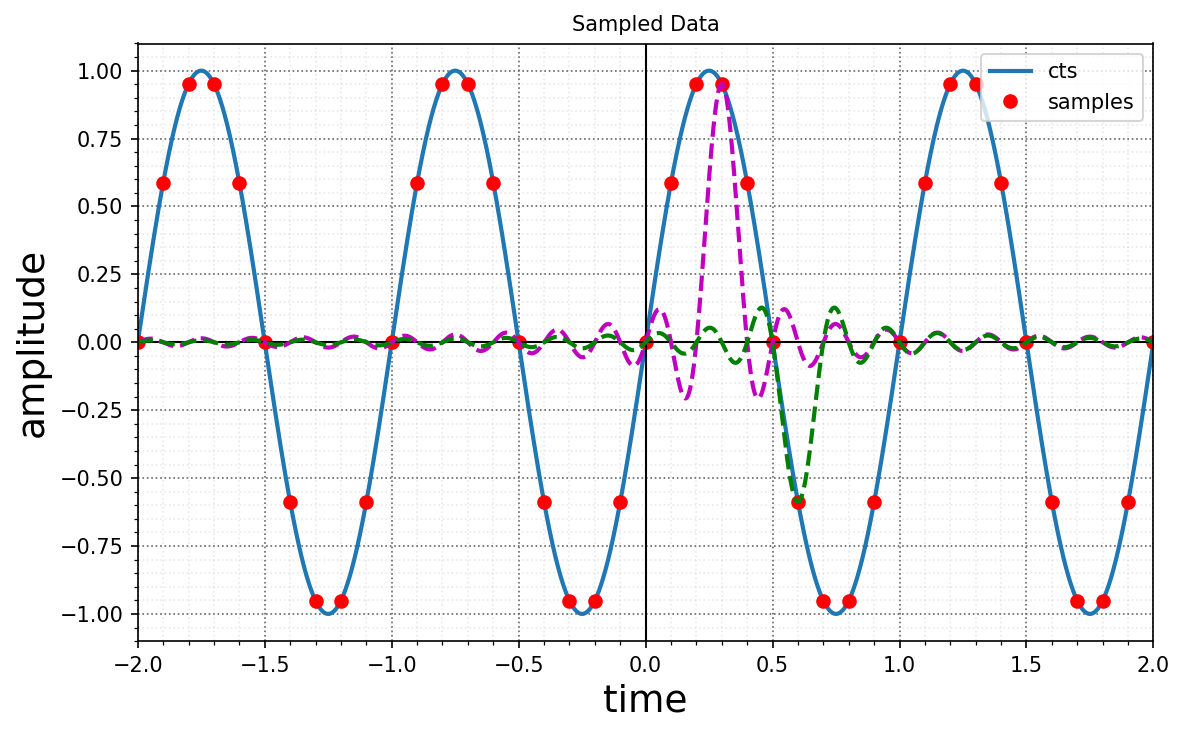

In [5]:
fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=150)
ax.plot(t_cts,x,label='cts')
ax.plot(t_discrete,xs,'ro',label='samples')
ax.set_xlim([-Tf, Tf])
ax.set_xlabel('time',fontsize=18)
ax.set_ylabel('amplitude',fontsize=18)
plt.title('Sampled Data')
bm.nicegrid()
plt.legend(loc=1)

jj = 23
interp = xs[jj] * np.sinc((t_cts - t_discrete[jj]) / Ts)
ax.plot(t_cts, interp, 'm--')

jj = 26
interp = xs[jj] * np.sinc((t_cts - t_discrete[jj]) / Ts)
ax.plot(t_cts, interp, 'g--')

fig.savefig('./figs/T9_ex3_1.pdf', dpi=300)
plt.show()

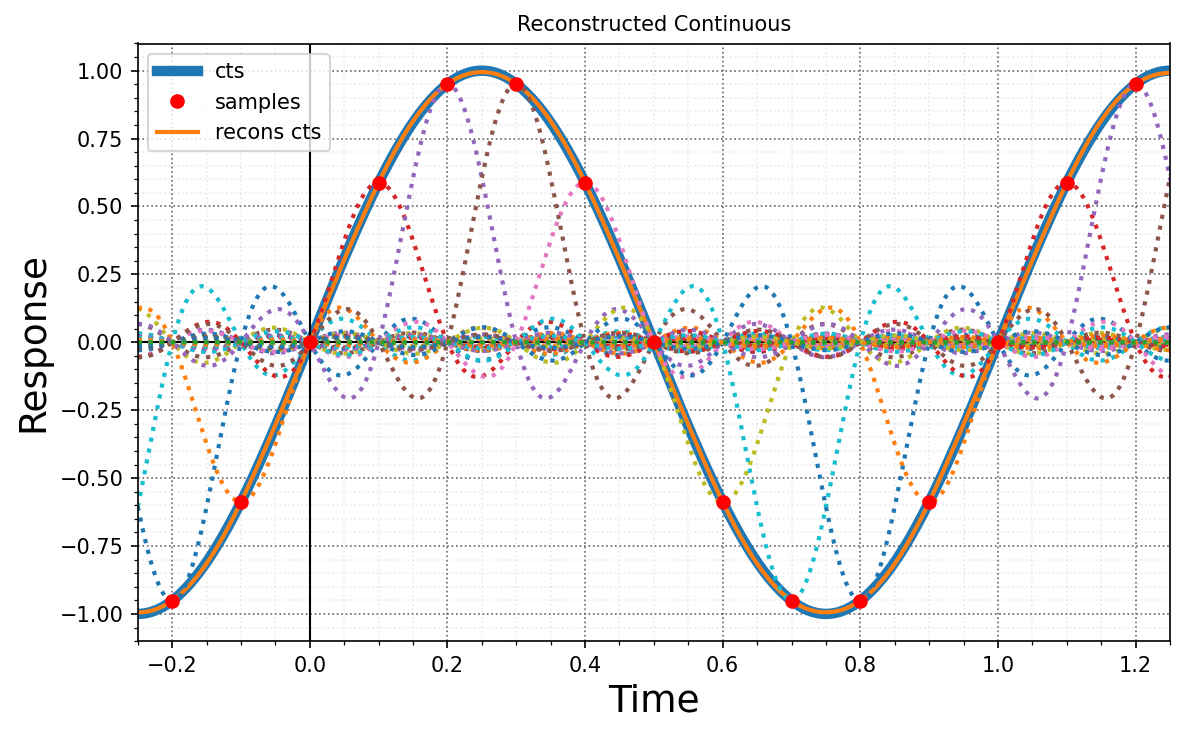

In [6]:
fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=150)
ax.plot(t_cts,x,label='cts',lw=5)
ax.plot(t_discrete,xs,'ro',label='samples',zorder=10)
ax.plot(t_cts,X,label='recons cts')
ax.set_xlim([-0.25, 1.25])
ax.set_xlabel('Time',fontsize=18)
ax.set_ylabel('Response',fontsize=18)
plt.title('Reconstructed Continuous')
bm.nicegrid()
plt.legend(loc=2)

for j, sample in enumerate(xs):
    interp = sample * np.sinc(t_cts/Ts - (j - len(xs)//2))
    plt.plot(t_cts, interp, ':')

fig.savefig('./figs/T9_ex3_2.pdf', dpi=300)
plt.show()

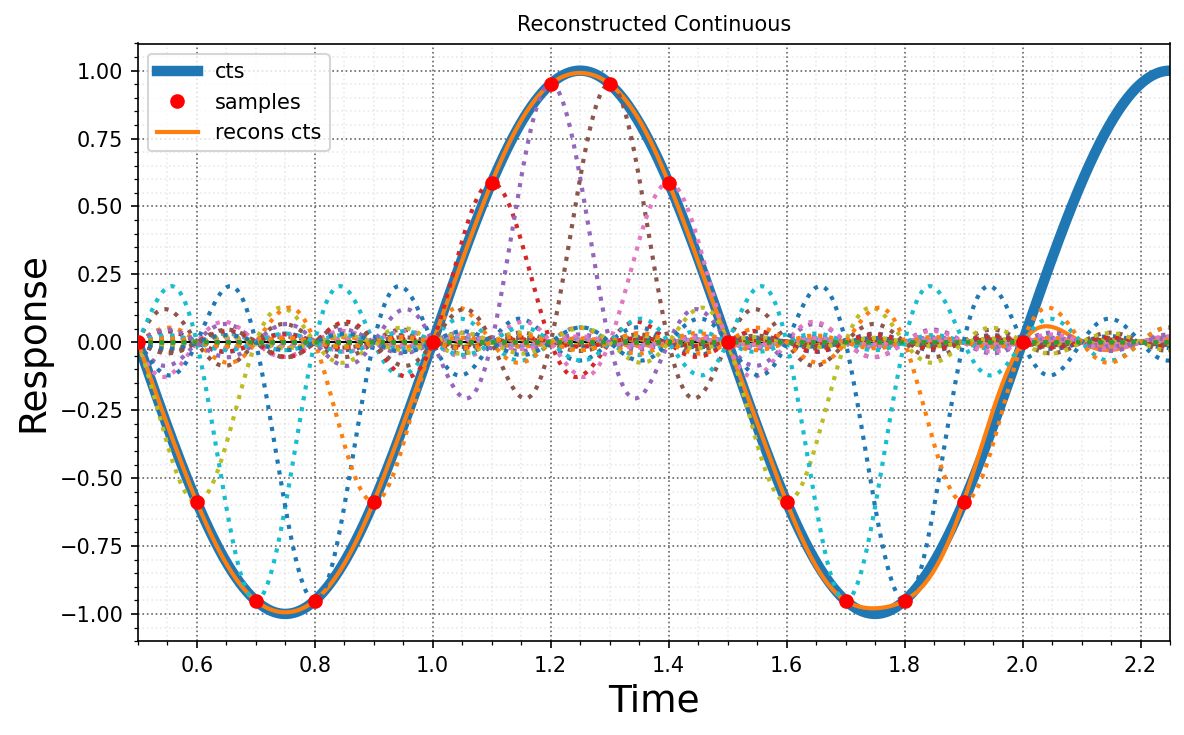

In [7]:
fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=150)
ax.plot(t_cts,x,label='cts',lw=5)
ax.plot(t_discrete,xs,'ro',label='samples',zorder=10)
ax.plot(t_cts,X,label='recons cts')
ax.set_xlim([0.5, 2.25])
ax.set_xlabel('Time',fontsize=18)
ax.set_ylabel('Response',fontsize=18)
plt.title('Reconstructed Continuous')
bm.nicegrid()
plt.legend(loc=2)

for j, sample in enumerate(xs):
    interp = sample * np.sinc(t_cts/Ts - (j - len(xs)//2))
    plt.plot(t_cts, interp, ':')

fig.savefig('./figs/T9_ex3_2a.pdf', dpi=300)
plt.show()

In [8]:
t_discrete


array([  -2.000,   -1.900,   -1.800,   -1.700,   -1.600,   -1.500,
         -1.400,   -1.300,   -1.200,   -1.100,   -1.000,   -0.900,
         -0.800,   -0.700,   -0.600,   -0.500,   -0.400,   -0.300,
         -0.200,   -0.100,    0.000,    0.100,    0.200,    0.300,
          0.400,    0.500,    0.600,    0.700,    0.800,    0.900,
          1.000,    1.100,    1.200,    1.300,    1.400,    1.500,
          1.600,    1.700,    1.800,    1.900,    2.000])

In [9]:
xs

array([   0.000,    0.588,    0.951,    0.951,    0.588,   -0.000,
         -0.588,   -0.951,   -0.951,   -0.588,    0.000,    0.588,
          0.951,    0.951,    0.588,   -0.000,   -0.588,   -0.951,
         -0.951,   -0.588,    0.000,    0.588,    0.951,    0.951,
          0.588,   -0.000,   -0.588,   -0.951,   -0.951,   -0.588,
          0.000,    0.588,    0.951,    0.951,    0.588,   -0.000,
         -0.588,   -0.951,   -0.951,   -0.588,    0.000])